# 09 - zachowanie modeli przy ekstremalnie małej liczbie etykiet
Rozszerzenie głównego eksperymentu o scenariusze 1% i 2% etykiet.
Cel: znalezienie progu poniżej którego modele sobie nie radzą
oraz sprawdzenie czy ranking architektur zmienia się w warunkach ekstremalnego niedoboru danych.

In [2]:
import os, json
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
from torch_geometric.datasets import Planetoid
from torch_geometric.nn import GCNConv, GATConv, SAGEConv, APPNP

os.makedirs('../models', exist_ok=True)
os.makedirs('../results', exist_ok=True)

dataset = Planetoid(root='../data/Cora', name='Cora')
data = dataset[0]
original_train_mask = data.train_mask.clone()

print(f'Węzły: {data.num_nodes}')
print()
# ile węzłów treningowych przy każdym progu?
for ratio in [0.01, 0.02, 0.05, 0.10, 0.20]:
    n = int(data.num_nodes * ratio)
    print(f'  {ratio:.0%}: {n} węzłów treningowych')

Węzły: 2708

  1%: 27 węzłów treningowych
  2%: 54 węzłów treningowych
  5%: 135 węzłów treningowych
  10%: 270 węzłów treningowych
  20%: 541 węzłów treningowych


## Wczytanie wyników

In [3]:
with open('../models/all_results.json') as f:
    existing_results = {
        name: {float(k): v for k, v in res.items()}
        for name, res in json.load(f).items()
        if name != 'MLP'
    }

gnn_models = ['GCN', 'GAT', 'GraphSAGE', 'APPNP']
seeds = [42, 123, 456, 789, 1000]

print('Istniejące wyniki (5-20%):')
print(f'{"Model":<12} {"5%":>14} {"10%":>14} {"20%":>14}')
print('-' * 58)
for name in gnn_models:
    row = f'{name:<12}'
    for ratio in [0.05, 0.10, 0.20]:
        accs = existing_results[name][ratio]
        row += f'  {np.mean(accs):.4f}±{np.std(accs):.4f}'
    print(row)

Istniejące wyniki (5-20%):
Model                    5%            10%            20%
----------------------------------------------------------
GCN           0.7922±0.0147  0.8152±0.0143  0.8274±0.0147
GAT           0.8058±0.0090  0.8208±0.0087  0.8448±0.0102
GraphSAGE     0.7952±0.0118  0.8218±0.0105  0.8424±0.0156
APPNP         0.8216±0.0101  0.8392±0.0126  0.8550±0.0113


## Architektury i funkcje pomocnicze

In [4]:
class GCN(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super().__init__()
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, out_channels)
    def forward(self, x, edge_index):
        x = F.relu(self.conv1(x, edge_index))
        x = F.dropout(x, p=0.5, training=self.training)
        return F.log_softmax(self.conv2(x, edge_index), dim=1)

class GAT(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, heads=8):
        super().__init__()
        self.conv1 = GATConv(in_channels, hidden_channels, heads=heads, dropout=0.6)
        self.conv2 = GATConv(hidden_channels * heads, out_channels, heads=1, dropout=0.6)
    def forward(self, x, edge_index):
        x = F.dropout(x, p=0.6, training=self.training)
        x = F.elu(self.conv1(x, edge_index))
        x = F.dropout(x, p=0.6, training=self.training)
        return F.log_softmax(self.conv2(x, edge_index), dim=1)

class GraphSAGE(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super().__init__()
        self.conv1 = SAGEConv(in_channels, hidden_channels)
        self.conv2 = SAGEConv(hidden_channels, out_channels)
    def forward(self, x, edge_index):
        x = F.relu(self.conv1(x, edge_index))
        x = F.dropout(x, p=0.5, training=self.training)
        return F.log_softmax(self.conv2(x, edge_index), dim=1)

class APPNPNet(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, K=10, alpha=0.1, dropout=0.5):
        super().__init__()
        self.fc1  = torch.nn.Linear(in_channels, hidden_channels)
        self.fc2  = torch.nn.Linear(hidden_channels, out_channels)
        self.prop = APPNP(K=K, alpha=alpha)
        self.dropout = dropout
    def forward(self, x, edge_index):
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = F.relu(self.fc1(x))
        x = F.dropout(x, p=self.dropout, training=self.training)
        return F.log_softmax(self.prop(self.fc2(x), edge_index), dim=1)

MODELS = {
    'GCN':       (GCN,       {'in_channels': dataset.num_features, 'hidden_channels': 64, 'out_channels': dataset.num_classes}),
    'GAT':       (GAT,       {'in_channels': dataset.num_features, 'hidden_channels': 8,  'out_channels': dataset.num_classes}),
    'GraphSAGE': (GraphSAGE, {'in_channels': dataset.num_features, 'hidden_channels': 64, 'out_channels': dataset.num_classes}),
    'APPNP':     (APPNPNet,  {'in_channels': dataset.num_features, 'hidden_channels': 64, 'out_channels': dataset.num_classes, 'K': 10, 'alpha': 0.1}),
}
OPTIMIZERS = {
    'GCN':       {'lr': 0.01},
    'GAT':       {'lr': 0.005, 'weight_decay': 5e-4},
    'GraphSAGE': {'lr': 0.01,  'weight_decay': 5e-4},
    'APPNP':     {'lr': 0.01,  'weight_decay': 5e-4},
}

def create_split(data, label_ratio, seed=42):
    torch.manual_seed(seed)
    np.random.seed(seed)
    available = (~data.test_mask).nonzero(as_tuple=True)[0]
    train_size = int(data.num_nodes * label_ratio)
    shuffled = available[torch.randperm(len(available))]
    mask = torch.zeros(data.num_nodes, dtype=torch.bool)
    mask[shuffled[:train_size]] = True
    return mask

def train(model, optimizer):
    model.train()
    optimizer.zero_grad()
    out = model(data.x, data.edge_index)
    F.nll_loss(out[data.train_mask], data.y[data.train_mask]).backward()
    optimizer.step()

def test(model):
    model.eval()
    with torch.no_grad():
        out = model(data.x, data.edge_index)
    pred = out.argmax(dim=1)
    return (pred[data.test_mask] == data.y[data.test_mask]).float().mean().item()

## Eksperymenty - 1% i 2% etykiet

In [5]:
low_ratios = [0.01, 0.02]
low_results = {name: defaultdict(list) for name in gnn_models}

for model_name, (ModelClass, model_kwargs) in MODELS.items():
    print(f'\n=== {model_name} ===')
    for ratio in low_ratios:
        for seed in seeds:
            data.train_mask = create_split(data, ratio, seed)

            model = ModelClass(**model_kwargs)
            optimizer = torch.optim.Adam(model.parameters(), **OPTIMIZERS[model_name])

            for epoch in range(200):
                train(model, optimizer)

            acc = test(model)
            low_results[model_name][ratio].append(acc)
            print(f'  {ratio:.0%}, Seed {seed}: {acc:.4f}')

data.train_mask = original_train_mask

print('\n--- Podsumowanie (1% i 2%) ---')
print(f'{"Model":<12} {"1%":>14} {"2%":>14}')
print('-' * 44)
for name in gnn_models:
    row = f'{name:<12}'
    for ratio in low_ratios:
        accs = low_results[name][ratio]
        row += f'  {np.mean(accs):.4f}±{np.std(accs):.4f}'
    print(row)


=== GCN ===
  1%, Seed 42: 0.5760
  1%, Seed 123: 0.5300
  1%, Seed 456: 0.4680
  1%, Seed 789: 0.6410
  1%, Seed 1000: 0.5520
  2%, Seed 42: 0.6960
  2%, Seed 123: 0.7270
  2%, Seed 456: 0.6860
  2%, Seed 789: 0.7450
  2%, Seed 1000: 0.7400

=== GAT ===
  1%, Seed 42: 0.6120
  1%, Seed 123: 0.5900
  1%, Seed 456: 0.5410
  1%, Seed 789: 0.6990
  1%, Seed 1000: 0.5420
  2%, Seed 42: 0.7060
  2%, Seed 123: 0.7490
  2%, Seed 456: 0.7380
  2%, Seed 789: 0.7550
  2%, Seed 1000: 0.7520

=== GraphSAGE ===
  1%, Seed 42: 0.4730
  1%, Seed 123: 0.5130
  1%, Seed 456: 0.5240
  1%, Seed 789: 0.6680
  1%, Seed 1000: 0.4920
  2%, Seed 42: 0.6750
  2%, Seed 123: 0.6130
  2%, Seed 456: 0.6990
  2%, Seed 789: 0.7180
  2%, Seed 1000: 0.6380

=== APPNP ===
  1%, Seed 42: 0.5980
  1%, Seed 123: 0.5920
  1%, Seed 456: 0.7110
  1%, Seed 789: 0.7490
  1%, Seed 1000: 0.6130
  2%, Seed 42: 0.7140
  2%, Seed 123: 0.7610
  2%, Seed 456: 0.7790
  2%, Seed 789: 0.8090
  2%, Seed 1000: 0.8010

--- Podsumowanie (1

## Pełne porównanie - 1% do 20%

In [7]:
all_ratios  = [0.01, 0.02, 0.05, 0.10, 0.20]
all_labels  = ['1%', '2%', '5%', '10%', '20%']

full_results = {}
for name in gnn_models:
    full_results[name] = {}
    for ratio in [0.01, 0.02]:
        full_results[name][ratio] = low_results[name][ratio]
    for ratio in [0.05, 0.10, 0.20]:
        full_results[name][ratio] = existing_results[name][ratio]

print(f'{"Model":<12} {"1%":>14} {"2%":>14} {"5%":>14} {"10%":>14} {"20%":>14}')
print('-' * 80)
for name in gnn_models:
    row = f'{name:<12}'
    for ratio in all_ratios:
        accs = full_results[name][ratio]
        row += f'  {np.mean(accs):.4f}±{np.std(accs):.4f}'
    print(row)

print('\n--- Ranking przy 1% etykiet ---')
ranking_1 = sorted(gnn_models, key=lambda n: np.mean(full_results[n][0.01]), reverse=True)
for i, name in enumerate(ranking_1):
    acc = np.mean(full_results[name][0.01])
    std = np.std(full_results[name][0.01])
    print(f'  {i+1}. {name:<12}: {acc:.4f} ± {std:.4f}')

Model                    1%             2%             5%            10%            20%
--------------------------------------------------------------------------------
GCN           0.5534±0.0566  0.7188±0.0237  0.7922±0.0147  0.8152±0.0143  0.8274±0.0147
GAT           0.5968±0.0580  0.7400±0.0179  0.8058±0.0090  0.8208±0.0087  0.8448±0.0102
GraphSAGE     0.5340±0.0693  0.6686±0.0386  0.7952±0.0118  0.8218±0.0105  0.8424±0.0156
APPNP         0.6526±0.0647  0.7728±0.0339  0.8216±0.0101  0.8392±0.0126  0.8550±0.0113

--- Ranking przy 1% etykiet ---
  1. APPNP       : 0.6526 ± 0.0647
  2. GAT         : 0.5968 ± 0.0580
  3. GCN         : 0.5534 ± 0.0566
  4. GraphSAGE   : 0.5340 ± 0.0693


## Wizualizacja - pełny zakres etykiet

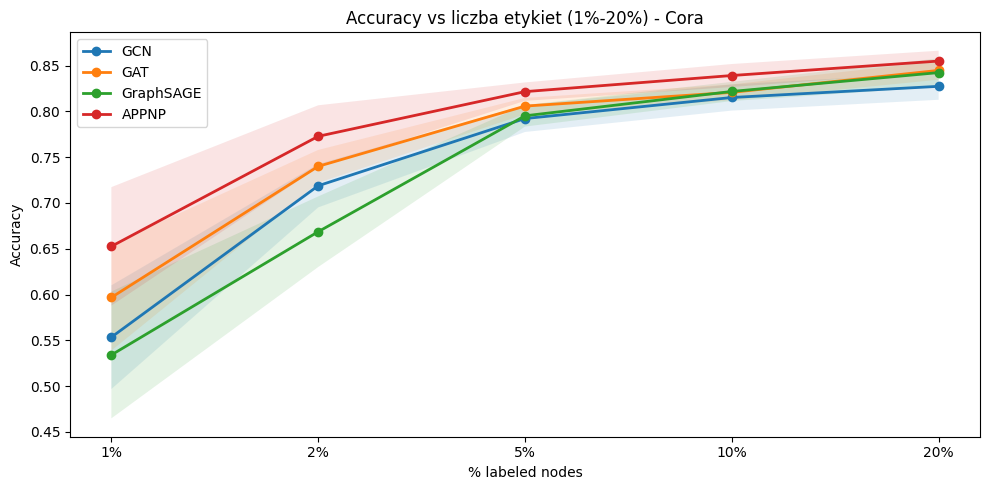

Wykres zapisany: ../results/full_label_range.png


In [8]:
plt.figure(figsize=(10, 5))
for name in gnn_models:
    means = [np.mean(full_results[name][r]) for r in all_ratios]
    stds  = [np.std(full_results[name][r])  for r in all_ratios]
    plt.plot(all_labels, means, marker='o',
            linewidth=2, label=name)
    plt.fill_between(all_labels,
                     [m - s for m, s in zip(means, stds)],
                     [m + s for m, s in zip(means, stds)],
                     alpha=0.12)

plt.xlabel('% labeled nodes')
plt.ylabel('Accuracy')
plt.title('Accuracy vs liczba etykiet (1%-20%) - Cora')
plt.legend()
plt.tight_layout()
plt.savefig('../results/full_label_range.png')
plt.show()
print('Wykres zapisany: ../results/full_label_range.png')

## Analiza spadku accuracy
Jak bardzo każdy model traci przechodząc z 5% do 1% etykiet?

In [9]:
print('--- Spadek accuracy względem 5% etykiet ---')
print(f'{"Model":<12} {"5% (baseline)":>16} {"2%":>12} {"1%":>12}')
print('-' * 55)
for name in gnn_models:
    base = np.mean(full_results[name][0.05])
    acc_2 = np.mean(full_results[name][0.02])
    acc_1 = np.mean(full_results[name][0.01])
    print(f'{name:<12} {base:>16.4f} {acc_2-base:>+12.4f} {acc_1-base:>+12.4f}')

print('\n--- Wariancja (czy modele są stabilne przy małej liczbie etykiet?) ---')
print(f'{"Model":<12} {"std 5%":>10} {"std 2%":>10} {"std 1%":>10}')
print('-' * 45)
for name in gnn_models:
    std_5 = np.std(full_results[name][0.05])
    std_2 = np.std(full_results[name][0.02])
    std_1 = np.std(full_results[name][0.01])
    print(f'{name:<12} {std_5:>10.4f} {std_2:>10.4f} {std_1:>10.4f}')

--- Spadek accuracy względem 5% etykiet ---
Model           5% (baseline)           2%           1%
-------------------------------------------------------
GCN                    0.7922      -0.0734      -0.2388
GAT                    0.8058      -0.0658      -0.2090
GraphSAGE              0.7952      -0.1266      -0.2612
APPNP                  0.8216      -0.0488      -0.1690

--- Wariancja (czy modele są stabilne przy małej liczbie etykiet?) ---
Model            std 5%     std 2%     std 1%
---------------------------------------------
GCN              0.0147     0.0237     0.0566
GAT              0.0090     0.0179     0.0580
GraphSAGE        0.0118     0.0386     0.0693
APPNP            0.0101     0.0339     0.0647


## Zapis wyników

In [10]:
low_serializable = {
    name: {str(k): v for k, v in res.items()}
    for name, res in low_results.items()
}
with open('../models/low_label_results.json', 'w') as f:
    json.dump(low_serializable, f, indent=2)

with open('../models/all_results.json') as f:
    all_raw = json.load(f)

for name in gnn_models:
    for ratio in [0.01, 0.02]:
        all_raw[name][str(ratio)] = low_results[name][ratio]

with open('../models/all_results.json', 'w') as f:
    json.dump(all_raw, f, indent=2)

print('Zapisano:')
print('  ../models/low_label_results.json')
print('  ../models/all_results.json  (zaktualizowany o 1% i 2%)')
print('  ../results/full_label_range.png')

Zapisano:
  ../models/low_label_results.json
  ../models/all_results.json  (zaktualizowany o 1% i 2%)
  ../results/full_label_range.png
